In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

df = pd.read_excel('../../jhani_pandit_dataset/Fitness_Survey__Responses_clean.xlsx')

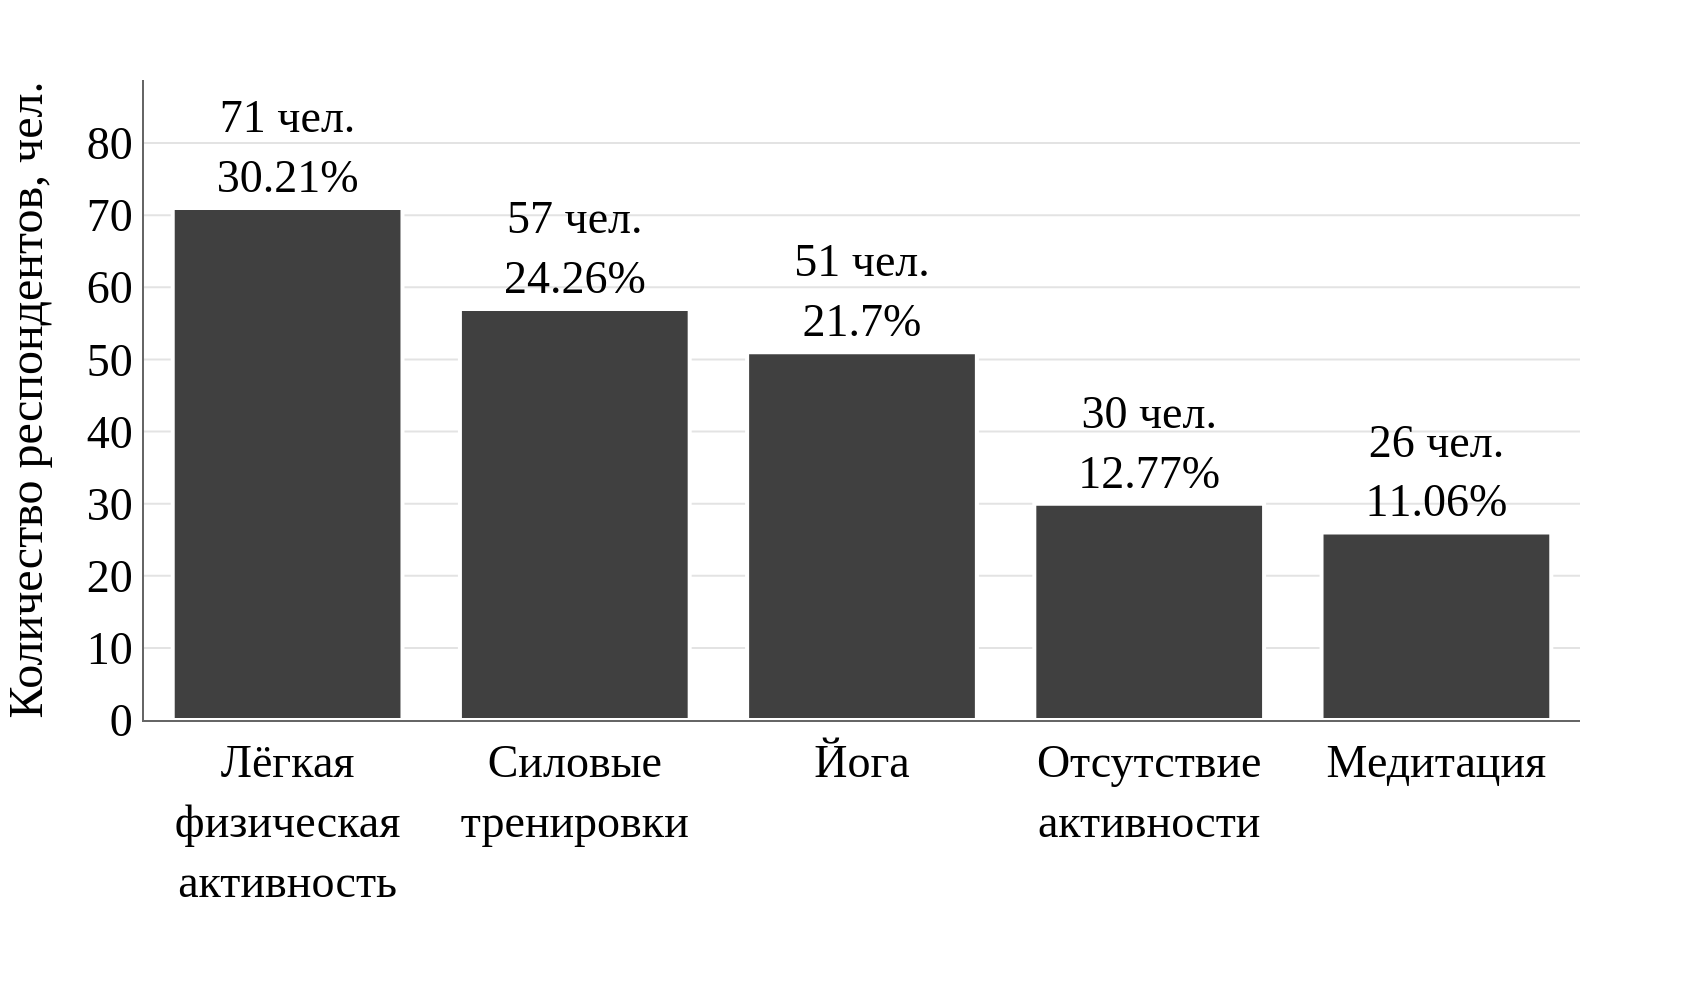

In [2]:
activity_counts = (
    df["Wellness/fitness_routine"]
    .value_counts()
    .sort_values(ascending=False)
)

activity_ru = {
    "Light physical activity": "Лёгкая<br>физическая<br>активность",
    "Rigorous physical exercise with equipments": "Силовые<br>тренировки",
    "Yoga": "Йога",
    "Meditation/mindfulness practice": "Медитация",
    "I don't follow any wellness/fitness routine": "Отсутствие<br>активности"
}

labels = [activity_ru.get(x, x) for x in activity_counts.index]
percents = (activity_counts / activity_counts.sum() * 100).round(2)

fig = go.Figure(data=[go.Bar(
    x=labels,
    y=activity_counts.values,
    text=[
        f'{count} чел.<br>{pct}%'
        for count, pct in zip(activity_counts.values, percents)
    ],
    textposition='outside',
    textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(
        color=PRIMARY,
        line=dict(color='white', width=2)
    ),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(
        title='',
        showgrid=False,
        tickfont=dict(size=23),
        linecolor=AXIS_COLOR,
        linewidth=1,
        tickangle=0
    ),
    yaxis=dict(
        title='Количество респондентов, чел.',
        titlefont=dict(size=24),
        tickfont=dict(size=23),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, activity_counts.max() * 1.25]
    ),
    margin=dict(l=60, r=60, t=40, b=100),
    width=850
)

fig.show()


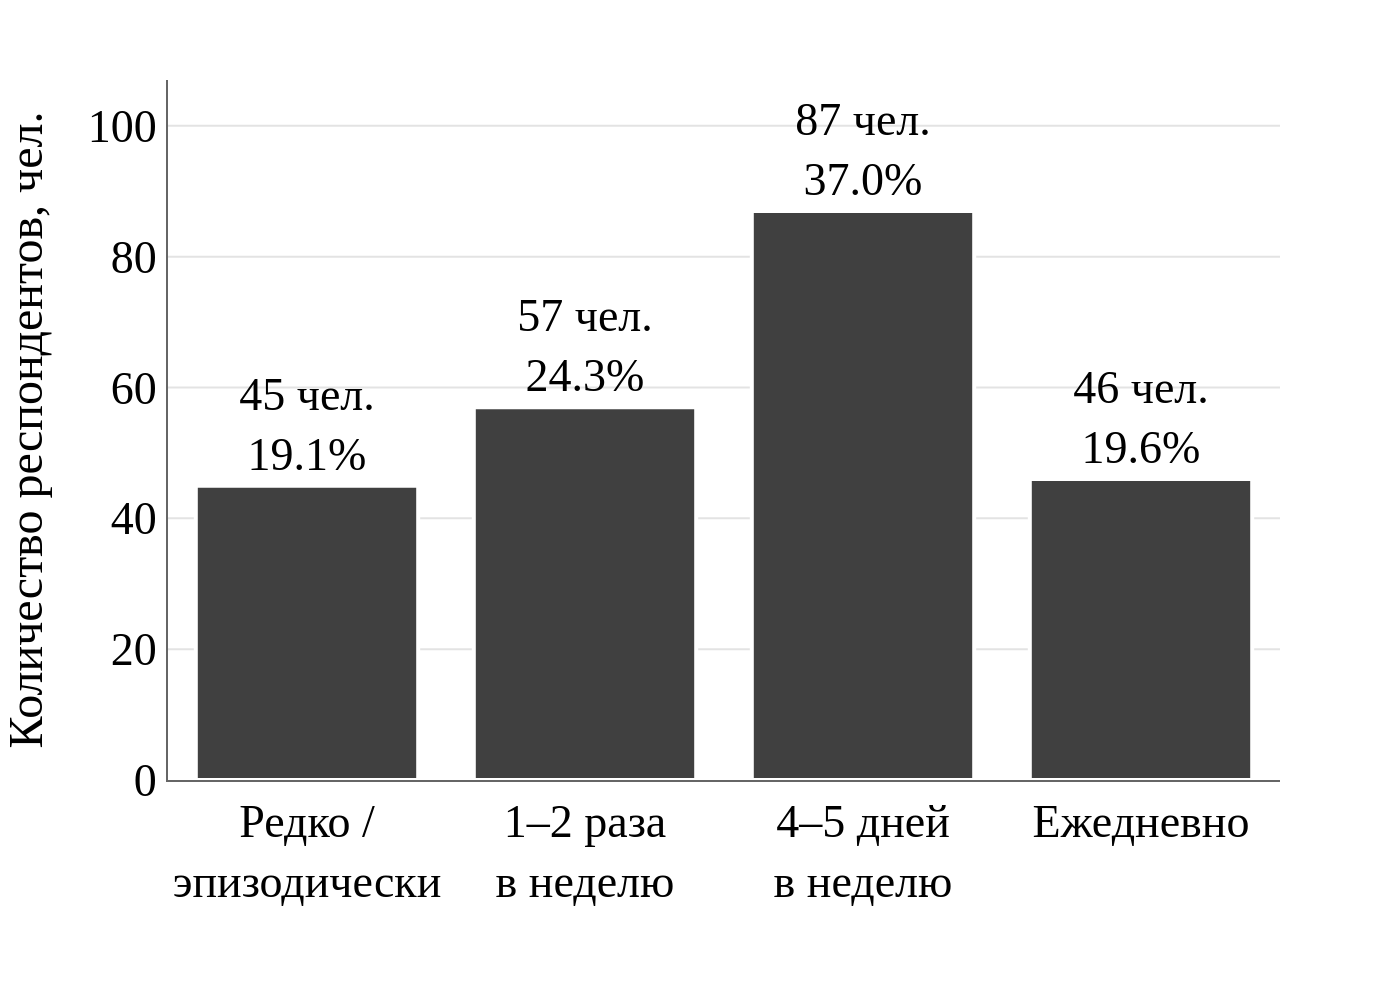

In [3]:
freq_col = "How often do you follow a wellness/fitness routine?"
freq_counts = df[freq_col].dropna().value_counts()

freq_order = [
    "Occasionally / Rarely",
    "Once/twice a week (e.g. weekends)",
    "2 to 3 days a week",
    "4 to 5 days a week",
    "Daily"
]

freq_counts = freq_counts.reindex(
    [f for f in freq_order if f in freq_counts.index]
)

freq_ru = {
    "Daily": "Ежедневно",
    "4 to 5 days a week": "4–5 дней<br>в неделю",
    "2 to 3 days a week": "2–3 дня<br>в неделю",
    "Once/twice a week (e.g. weekends)": "1–2 раза<br>в неделю",
    "Occasionally / Rarely": "Редко /<br>эпизодически"
}

labels = [freq_ru[x] for x in freq_counts.index]
freq_percent = (freq_counts / freq_counts.sum() * 100).round(1)

fig = go.Figure(data=[go.Bar(
    x=labels,
    y=freq_counts.values,
    text=[
        f'{count} чел.<br>{pct}%'
        for count, pct in zip(freq_counts.values, freq_percent)
    ],
    textposition='outside',
    textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(
        color=PRIMARY,
        line=dict(color='white', width=2)
    ),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(
        title='',
        showgrid=False,
        tickfont=dict(size=23),
        linecolor=AXIS_COLOR,
        linewidth=1,
        tickangle=0
    ),
    yaxis=dict(
        title='Количество респондентов, чел.',
        titlefont=dict(size=24),
        tickfont=dict(size=23),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, freq_counts.max() * 1.23]
    ),
    margin=dict(l=60, r=60, t=40, b=100)
)

fig.show()

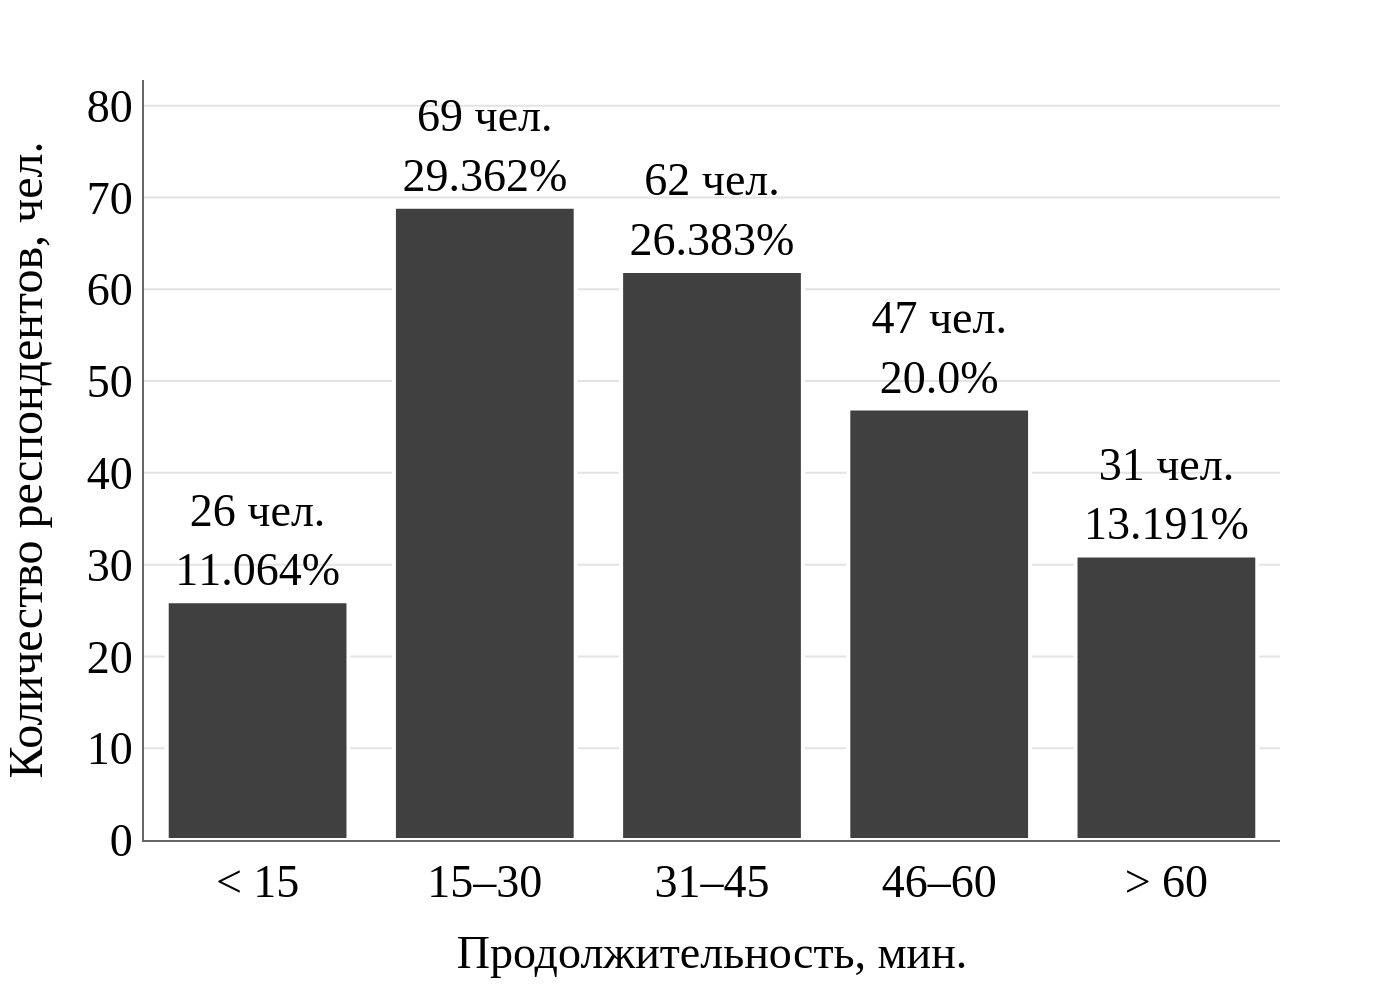

In [4]:
time_col = (
    "Whenever you practice your wellness/fitness routine, "
    "how much time on average do you spend (in minutes)?"
)

time_data = df[time_col].dropna()

time_order = ["Less than 15", "15-30", "31-45", "46-60", "More than 60"]
time_counts = time_data.value_counts().reindex(time_order, fill_value=0)

time_ru = {
    "Less than 15": "< 15",
    "15-30": "15–30",
    "31-45": "31–45",
    "46-60": "46–60",
    "More than 60": "> 60"
}

labels = [time_ru[t] for t in time_counts.index]
time_percent = (time_counts / time_counts.sum() * 100).round(3)

fig = go.Figure(data=[go.Bar(
    x=labels,
    y=time_counts.values,
    text=[
        f'{count} чел.<br>{pct}%'
        for count, pct in zip(time_counts.values, time_percent)
    ],
    textposition='outside',
    textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(
        color=PRIMARY,
        line=dict(color='white', width=2)
    ),
    hovertemplate='<b>%{x} минут</b><br>Количество: %{y} чел.<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(
        title='Продолжительность, мин.',
        titlefont=dict(size=23, family='Times New Roman', color='#000000'),
        showgrid=False,
        tickfont=dict(size=23),
        linecolor=AXIS_COLOR,
        linewidth=1,
        tickangle=0
    ),
    yaxis=dict(
        title='Количество респондентов, чел.',
        titlefont=dict(size=24),
        tickfont=dict(size=23),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, time_counts.max() * 1.2]
    ),
    margin=dict(l=60, r=60, t=40, b=80)
)

fig.show()

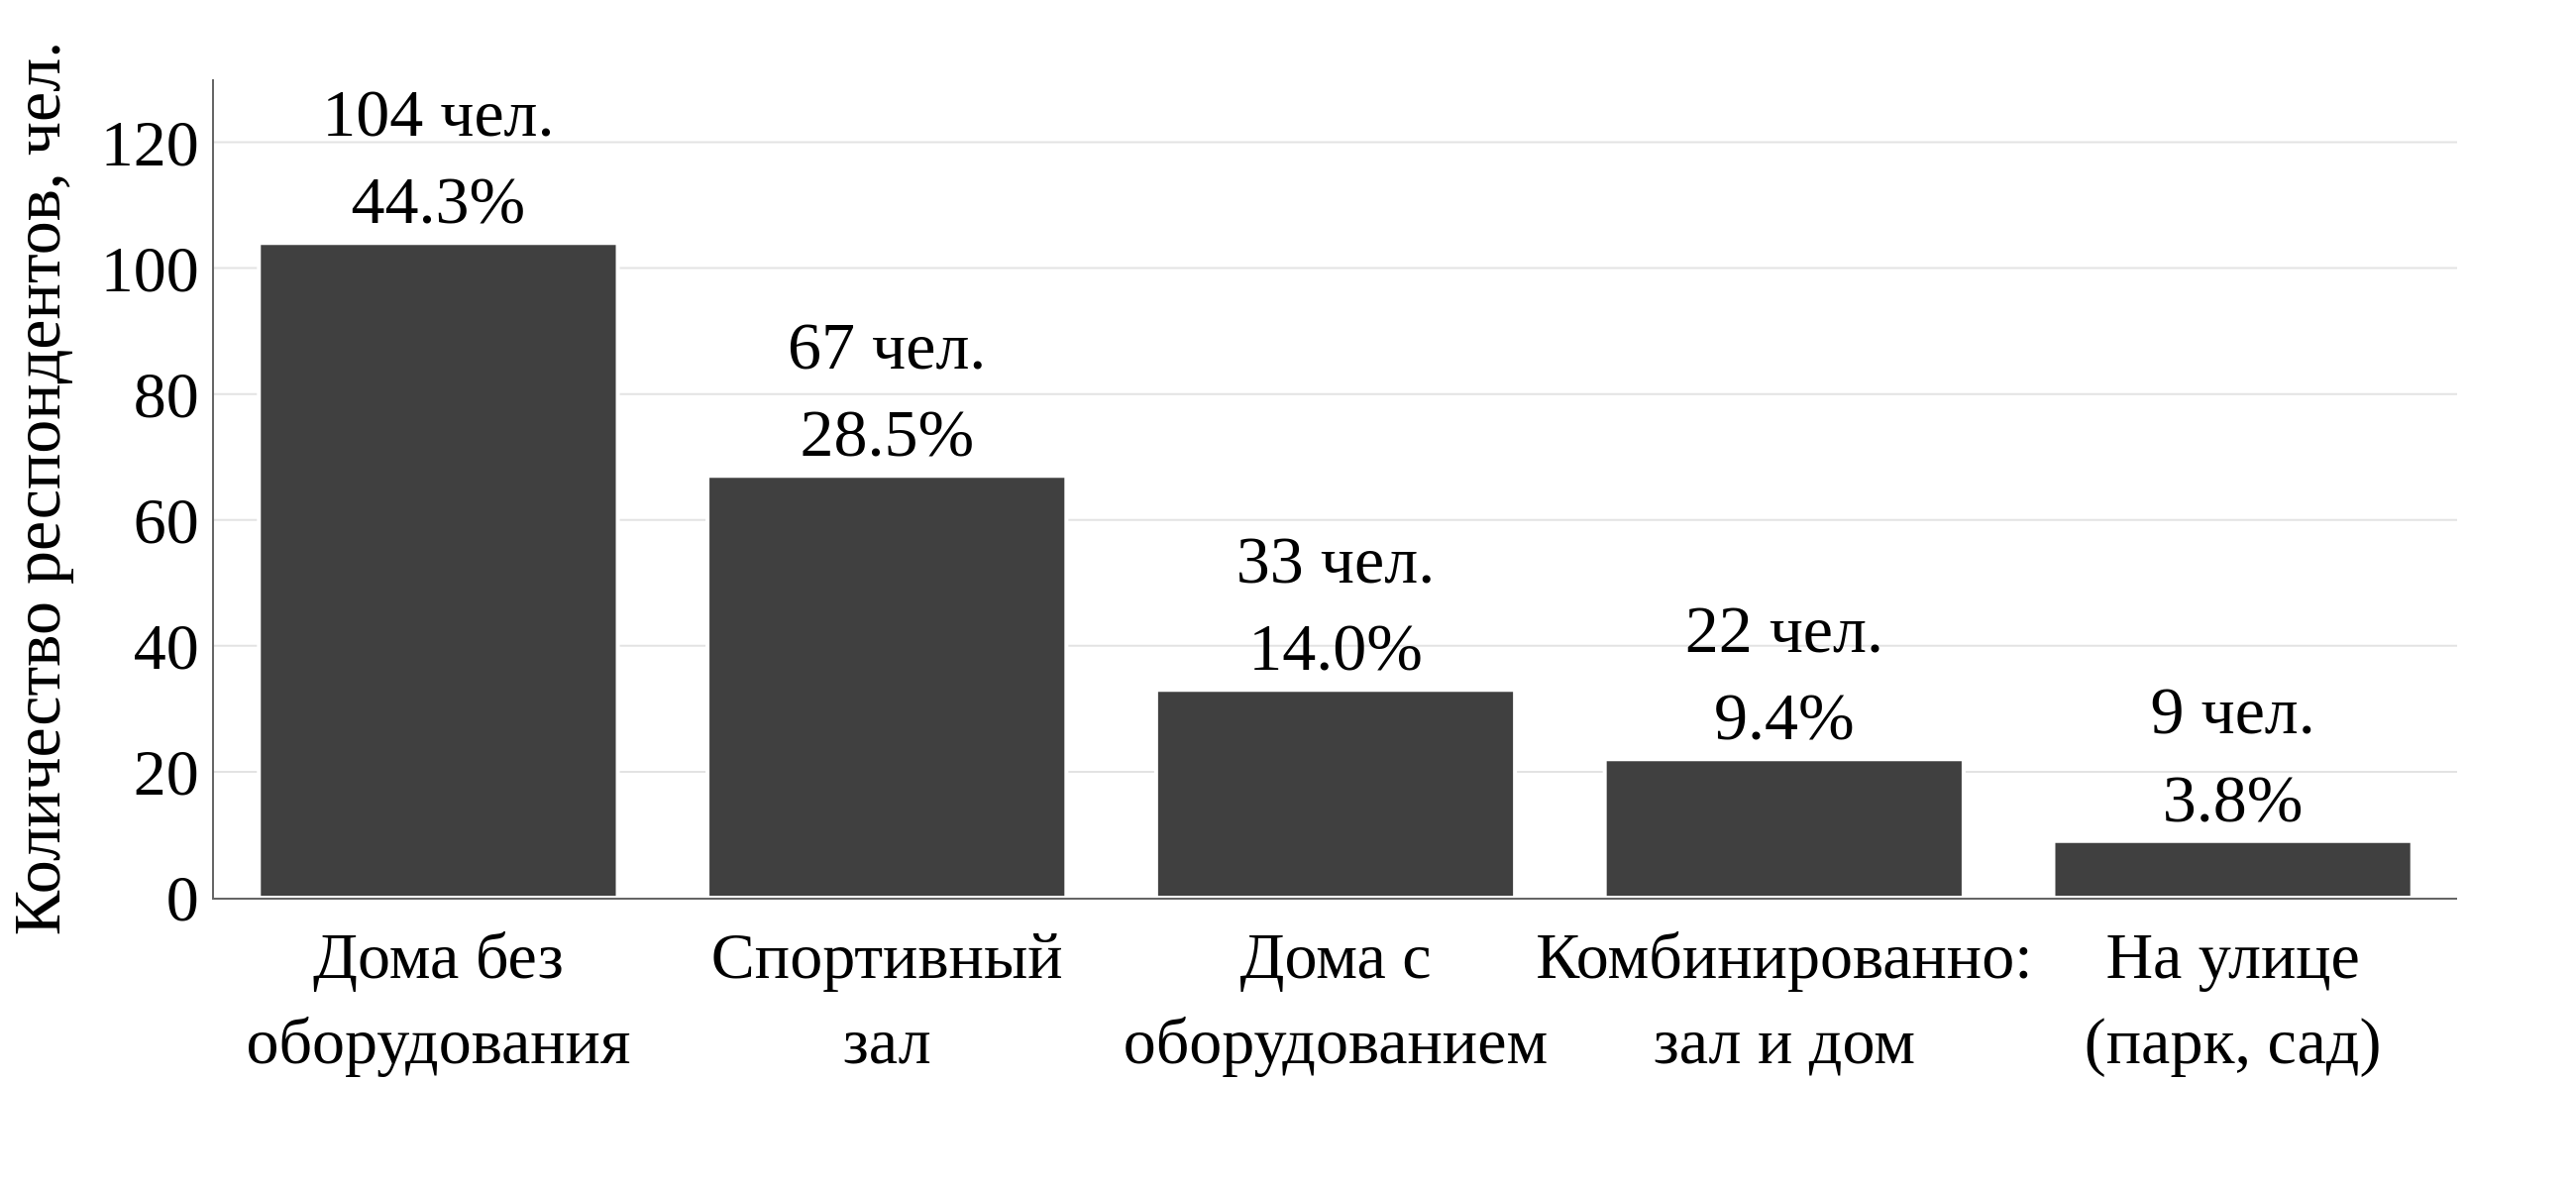

In [5]:
place_counts = (
    df["Place of wellness/fitness routine"]
    .value_counts()
    .sort_values(ascending=False)
)

place_ru = {
    "Home - without equipment": "Дома без<br>оборудования",
    "Gym": "Спортивный<br>зал",
    "Home - with equipment": "Дома с<br>оборудованием",
    "Hybrid - gym and at home": "Комбинированно:<br>зал и дом",
    "Outdoor": "На улице<br>(парк, сад)"
}

labels = [place_ru.get(x, x) for x in place_counts.index]
percents = (place_counts / place_counts.sum() * 100).round(1)

fig = go.Figure(data=[go.Bar(
    x=labels,
    y=place_counts.values,
    text=[
        f'{count} чел.<br>{pct}%'
        for count, pct in zip(place_counts.values, percents)
    ],
    textposition='outside',
    textfont=dict(size=34, color='#000000', family='Times New Roman'),
    marker=dict(
        color=PRIMARY,
        line=dict(color='white', width=2)
    ),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=33, color='#000000'),
    xaxis=dict(
        title='',
        showgrid=False,
        tickfont=dict(size=33),
        linecolor=AXIS_COLOR,
        linewidth=1,
        tickangle=0
    ),
    yaxis=dict(
        title='Количество респондентов, чел.',
        titlefont=dict(size=34),
        tickfont=dict(size=33),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, place_counts.max() * 1.25]
    ),
    margin=dict(l=60, r=60, t=40, b=120),
    width=1300,
    height=600
)

fig.show()